In [1]:
#Importing libraries
import pandas as pd
import numpy as np
%matplotlib inline
from matplotlib import pyplot as plt
import matplotlib
matplotlib.rcParams["figure.figsize"] = (20,10)

In [2]:
#Reading the csv to a pandas dataframe
df1 = pd.read_csv(r"D:\ML Projects\Real Estate Price Prediction Project\New prices.csv")
df1.head()

,BEDROOMS,PROPERTY TYPE,HAS GYM,EN SUITE,SWIMMING POOL,Has DSQ,Has GARDEN,LOCATION,SELLING PRICE
0,6,Villa,0,1,0,0,0,Kiambu Road,"130,000,000"
1,4,Townhouse,0,1,0,1,0,Kiambu Road,"26,950,000"
2,4,Villa,0,1,0,0,0,Ongata Rongai,"16,000,000"
3,5,House,0,1,0,0,0,Ngong Road,"45,000,000"
4,5,Townhouse,0,1,0,0,0,Lavington,"72,000,000"


### EDA

In [3]:
df1.shape

(1847, 9)

In [4]:
df1.describe()

,BEDROOMS,HAS GYM,EN SUITE,SWIMMING POOL,Has DSQ,Has GARDEN
count,1847.000000,1847.000000,1847.000000,1847.000000,1847.000000,1847.000000
mean,4.187331,0.002707,0.789930,0.027071,0.067677,0.010828
std,1.022812,0.051973,0.407469,0.162334,0.251259,0.103523
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,5.000000,0.000000,1.000000,0.000000,0.000000,0.000000
max,9.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1847 entries, 0 to 1846
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   BEDROOMS        1847 non-null   int64 
 1   PROPERTY TYPE   1847 non-null   object
 2   HAS GYM         1847 non-null   int64 
 3   EN SUITE        1847 non-null   int64 
 4   SWIMMING POOL   1847 non-null   int64 
 5   Has DSQ         1847 non-null   int64 
 6   Has GARDEN      1847 non-null   int64 
 7   LOCATION        1847 non-null   object
 8   SELLING PRICE   1847 non-null   object
dtypes: int64(6), object(3)
memory usage: 130.0+ KB


In [6]:
# note that selling price was not descibed,because the column is still being treated as object/string instead of numeric. 


In [7]:
df1.columns

Index(['BEDROOMS', 'PROPERTY TYPE', 'HAS GYM', 'EN SUITE', 'SWIMMING POOL',
       'Has DSQ', 'Has GARDEN', 'LOCATION', 'SELLING PRICE '],
      dtype='object')

In [8]:
#stripping the columns
df1.columns = df1.columns.str.strip()

In [9]:
df1['SELLING PRICE'] = (
    df1['SELLING PRICE']
    .astype(str)
    .str.replace(',', '')
    .str.replace('KSh', '')
    .str.strip()
)

df1['SELLING PRICE'] = pd.to_numeric(df1['SELLING PRICE'], errors='coerce')

In [10]:
df1.describe()

,BEDROOMS,HAS GYM,EN SUITE,SWIMMING POOL,Has DSQ,Has GARDEN,SELLING PRICE
count,1847.000000,1847.000000,1847.000000,1847.000000,1847.000000,1847.000000,1.847000e+03
mean,4.187331,0.002707,0.789930,0.027071,0.067677,0.010828,6.103149e+07
std,1.022812,0.051973,0.407469,0.162334,0.251259,0.103523,7.086048e+07
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.700000e+06
25%,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.649950e+07
50%,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,3.950000e+07
75%,5.000000,0.000000,1.000000,0.000000,0.000000,0.000000,8.000000e+07
max,9.000000,1.000000,1.000000,1.000000,1.000000,1.000000,6.840000e+08


In [11]:
#Checking if there maybe any null value. However none is expected since the data was cleaned in excel. 
df1.isnull().sum()

BEDROOMS         0
PROPERTY TYPE    0
HAS GYM          0
EN SUITE         0
SWIMMING POOL    0
Has DSQ          0
Has GARDEN       0
LOCATION         0
SELLING PRICE    0
dtype: int64

#### Feature Engineering

In [12]:
df1.LOCATION.unique()

array(['Kiambu Road', 'Ongata Rongai', 'Ngong Road', 'Lavington',
       'Westlands', 'Kileleshwa', 'Muthaiga', 'Kiserian', 'Athi River',
       'Kikuyu', 'Ngumo Estate', 'Langata', 'Watamu', 'Nyali', 'Naivasha',
       'Ruiru', 'Ngong', 'Broadway', 'Mombasa Island', 'Bamburi',
       'Mtwapa', 'Kilimani', 'Kenyatta Road', 'Vipingo', 'Malindi',
       'Karen', 'Syokimau', 'Kitengela', 'Juja', 'Animo', 'Ruaka',
       'Ruiru-Githunguri Road', 'Muchatha and Banana', 'Nyali Area',
       'Kamulu Joska Malaa', 'Buruburu', 'Kilifi', 'Karen Hardy',
       'Katani', 'Jumba Ruins', 'Nanyuki', 'Eastern ByPass', 'Limuru',
       'Mombasa Road', 'Kikambala', 'Ukunda', 'Gasaro', 'Kisumu',
       'South C', 'Thika Road', 'Neptune', 'Thika', 'South B', 'Diani',
       'Nairobi', 'Ridgeways', 'Jamhuri', "Murang'a County",
       'Posta Mtwapa', 'Milimani', 'Kisaju', 'Roysambu', 'Kilifi County',
       'Shanzu', 'Thindigua', 'Aloo drive', 'Komarock',
       'La-marina Mtwapa', 'Kajiado County', 'Utawa

In [13]:
len(df1.LOCATION.unique())

103

In [14]:
location_stats = df1['LOCATION'].value_counts(ascending=False)
print(location_stats)

LOCATION
Westlands    366
Lavington    193
Ruiru        109
Kitengela    108
Karen        102
            ... 
Utawala        1
Isinya         1
Posta          1
Kasarani       1
Kajiado        1
Name: count, Length: 103, dtype: int64


In [15]:
location_stats.values.sum()

np.int64(1847)

In [16]:
len(location_stats[location_stats>10])

32

In [17]:
len(location_stats[location_stats<=10])

71

###### Any location having less than 10 data points should be tagged as "other" location. This way number of categories can be reduced by huge amount. Later on when we do one hot encoding, it will help us with having fewer dummy columns. 
32 Locations have more than 10 

In [18]:
(location_stats[location_stats<=10])

LOCATION
Buruburu        10
Mombasa Road    10
Ridgeways        9
Watamu           9
Naivasha         8
                ..
Utawala          1
Isinya           1
Posta            1
Kasarani         1
Kajiado          1
Name: count, Length: 71, dtype: int64

In [19]:
location_stats_less_than_10 = location_stats[location_stats<=10]

df1.LOCATION = df1.LOCATION.apply(lambda x: 'other' if x in location_stats_less_than_10 else x)
len(df1.LOCATION.unique())

33

## FEATURE ENGINEERING

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import matplotlib
matplotlib.rcParams["figure.figsize"] = (20, 10)


print("Shape:", df1.shape)
print("Columns:", df1.columns.tolist())
print("Nulls:\n", df1.isnull().sum())
print("SELLING PRICE dtype:", df1['SELLING PRICE'].dtype)

Shape: (1847, 9)
Columns: ['BEDROOMS', 'PROPERTY TYPE', 'HAS GYM', 'EN SUITE', 'SWIMMING POOL', 'Has DSQ', 'Has GARDEN', 'LOCATION', 'SELLING PRICE']
Nulls:
 BEDROOMS         0
PROPERTY TYPE    0
HAS GYM          0
EN SUITE         0
SWIMMING POOL    0
Has DSQ          0
Has GARDEN       0
LOCATION         0
SELLING PRICE    0
dtype: int64
SELLING PRICE dtype: int64


In [21]:
# Drop any rows where SELLING PRICE is NaN 
# (pd.to_numeric with errors='coerce' may have introduced NaNs)
df1.dropna(subset=['SELLING PRICE'], inplace=True)
print("Shape after dropping NaN prices:", df1.shape)

Shape after dropping NaN prices: (1847, 9)


In [23]:
# Encode PROPERTY TYPE (One-Hot Encoding) 
# WHY: ML models cannot work with raw text categories.
# One-hot encoding converts each property type into a binary
# column so the model treats them as distinct categories,not ordered numbers.

print("Property Types:\n", df1['PROPERTY TYPE'].value_counts())

Property Types:
 PROPERTY TYPE
House           889
Townhouse       490
Villa           261
NOT PROVIDED    207
Name: count, dtype: int64


In [24]:
# Amenities Score (Feature Interaction) 
# WHY: Instead of treating each amenity independently, combining them into a single "luxury score" captures the cumulative effect of amenities on price. A property with 3 amenities is likely priced significantly higher than one with 1.

df1['AMENITY_SCORE'] = (
    df1['HAS GYM'] +
    df1['EN SUITE'] +
    df1['SWIMMING POOL'] +
    df1['Has DSQ'] +
    df1['Has GARDEN']
)

print("Amenity Score distribution:\n", df1['AMENITY_SCORE'].value_counts().sort_index())

Amenity Score distribution:
 AMENITY_SCORE
0     316
1    1403
2     128
Name: count, dtype: int64


In [25]:
# Bedroom Tier (Feature Binning)
# WHY: Binning bedrooms into tiers captures non-linear price jumps between property sizes. The price difference between 1→2 bedrooms is not the same as 5→6 bedrooms. Tiers reflect how buyers/sellers think about property size segments.

def bedroom_tier(n):
    if n <= 2:
        return 'Small'       # Studios / 1-2 bed apartments
    elif n <= 4:
        return 'Medium'      # Most common family homes
    elif n <= 6:
        return 'Large'       # Executive homes
    else:
        return 'Luxury'      # Mansions / villas

df1['BEDROOM_TIER'] = df1['BEDROOMS'].apply(bedroom_tier)
print("Bedroom Tier distribution:\n", df1['BEDROOM_TIER'].value_counts())

Bedroom Tier distribution:
 BEDROOM_TIER
Medium    1196
Large      574
Luxury      43
Small       34
Name: count, dtype: int64


#### Location Tier (Domain Knowledge Encoding) 
##### WHY: In Nairobi real estate, location is the STRONGEST price driver. Karen, Muthaiga, Westlands command premium prices.Encoding locations into tiers captures this price hierarchy without needing hundreds of dummy columns.


In [26]:

premium_locations = [
    'Karen', 'Muthaiga', 'Lavington', 'Kileleshwa',
    'Westlands', 'Kilimani', 'Ridgeways', 'Gigiri'
]

mid_locations = [
    'Ngong Road', 'Kiambu Road', 'Thika Road', 'Ruaka',
    'Runda', 'Nyali', 'South C', 'South B', 'Langata',
    'Ngumo Estate', 'Roysambu', 'Thindigua', 'Kasarani',
    'Mombasa Road', 'Buruburu', 'Donholm', 'Imara Daima',
    'Ruiru', 'Juja', 'Embakasi', 'Dagoretti Corner'
]

# Everything else (including 'other') → Affordable

def location_tier(loc):
    if loc in premium_locations:
        return 'Premium'
    elif loc in mid_locations:
        return 'Mid'
    else:
        return 'Affordable'

df1['LOCATION_TIER'] = df1['LOCATION'].apply(location_tier)
print("Location Tier distribution:\n", df1['LOCATION_TIER'].value_counts())

Location Tier distribution:
 LOCATION_TIER
Affordable    743
Premium       723
Mid           381
Name: count, dtype: int64


### Price per Bedroom (Target-derived insight) 
##### WHY: We won't use this as a model feature (data leakage risk), but we compute it now for EDA / outlier detection purposes.

In [27]:
df1['PRICE_PER_BEDROOM'] = df1['SELLING PRICE'] / df1['BEDROOMS']
print("Price per bedroom stats:\n", df1['PRICE_PER_BEDROOM'].describe())

Price per bedroom stats:
 count    1.847000e+03
mean     1.392885e+07
std      2.078939e+07
min      1.233333e+06
25%      4.333333e+06
50%      9.690000e+06
75%      1.800000e+07
max      6.000000e+08
Name: PRICE_PER_BEDROOM, dtype: float64


#### One-Hot Encode Categorical Columns 
##### WHY: We encode PROPERTY TYPE, BEDROOM_TIER, LOCATION_TIER,and LOCATION. We use drop_first=False so we don't lose info, and we'll let the model handle multicollinearity via regularization (Ridge/Lasso).

In [28]:


df_encoded = pd.get_dummies(
    df1,
    columns=['PROPERTY TYPE', 'LOCATION', 'BEDROOM_TIER', 'LOCATION_TIER'],
    drop_first=False
)

# Drop EDA-only columns not needed for modeling
df_encoded.drop(columns=['PRICE_PER_BEDROOM'], inplace=True)

print("Shape after encoding:", df_encoded.shape)
print("Columns:\n", df_encoded.columns.tolist())

Shape after encoding: (1847, 52)
Columns:
 ['BEDROOMS', 'HAS GYM', 'EN SUITE', 'SWIMMING POOL', 'Has DSQ', 'Has GARDEN', 'SELLING PRICE', 'AMENITY_SCORE', 'PROPERTY TYPE_House', 'PROPERTY TYPE_NOT PROVIDED', 'PROPERTY TYPE_Townhouse', 'PROPERTY TYPE_Villa', 'LOCATION_Athi River', 'LOCATION_Bamburi', 'LOCATION_Diani', 'LOCATION_Juja', 'LOCATION_Kamulu Joska Malaa', 'LOCATION_Karen', 'LOCATION_Kenyatta Road', 'LOCATION_Kiambu Road', 'LOCATION_Kikambala', 'LOCATION_Kikuyu', 'LOCATION_Kileleshwa', 'LOCATION_Kilimani', 'LOCATION_Kitengela', 'LOCATION_Langata', 'LOCATION_Lavington', 'LOCATION_Limuru', 'LOCATION_Malindi', 'LOCATION_Mombasa Island', 'LOCATION_Mtwapa', 'LOCATION_Muthaiga', 'LOCATION_Ngong', 'LOCATION_Nyali', 'LOCATION_Nyali Area', 'LOCATION_Ongata Rongai', 'LOCATION_Roysambu', 'LOCATION_Ruiru', 'LOCATION_Shanzu', 'LOCATION_South C', 'LOCATION_Syokimau', 'LOCATION_Thika', 'LOCATION_Vipingo', 'LOCATION_Westlands', 'LOCATION_other', 'BEDROOM_TIER_Large', 'BEDROOM_TIER_Luxury', 'BE

## OUTLIER DETECTION & REMOVAL

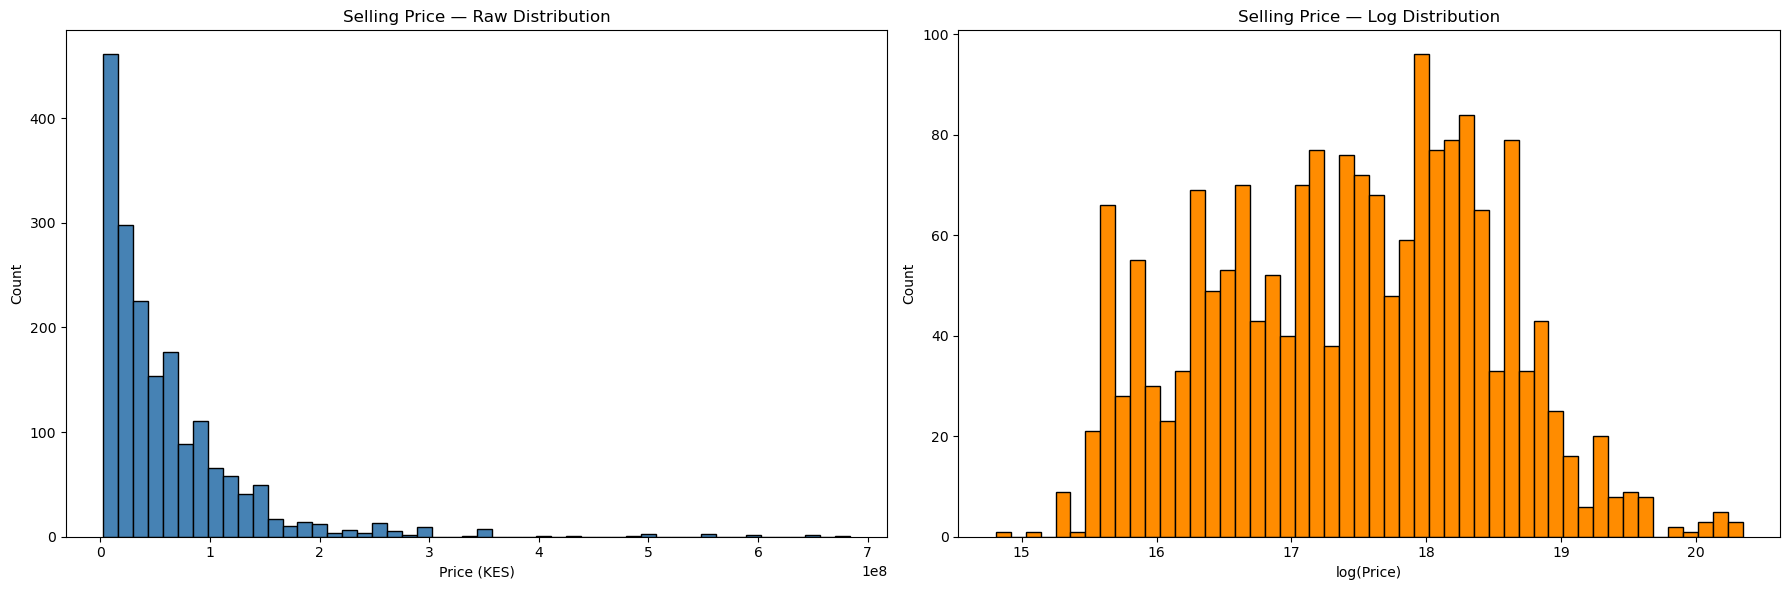

In [29]:
# Visualize SELLING PRICE distribution 
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].hist(df1['SELLING PRICE'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Selling Price — Raw Distribution')
axes[0].set_xlabel('Price (KES)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df1['SELLING PRICE']), bins=50, color='darkorange', edgecolor='black')
axes[1].set_title('Selling Price — Log Distribution')
axes[1].set_xlabel('log(Price)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

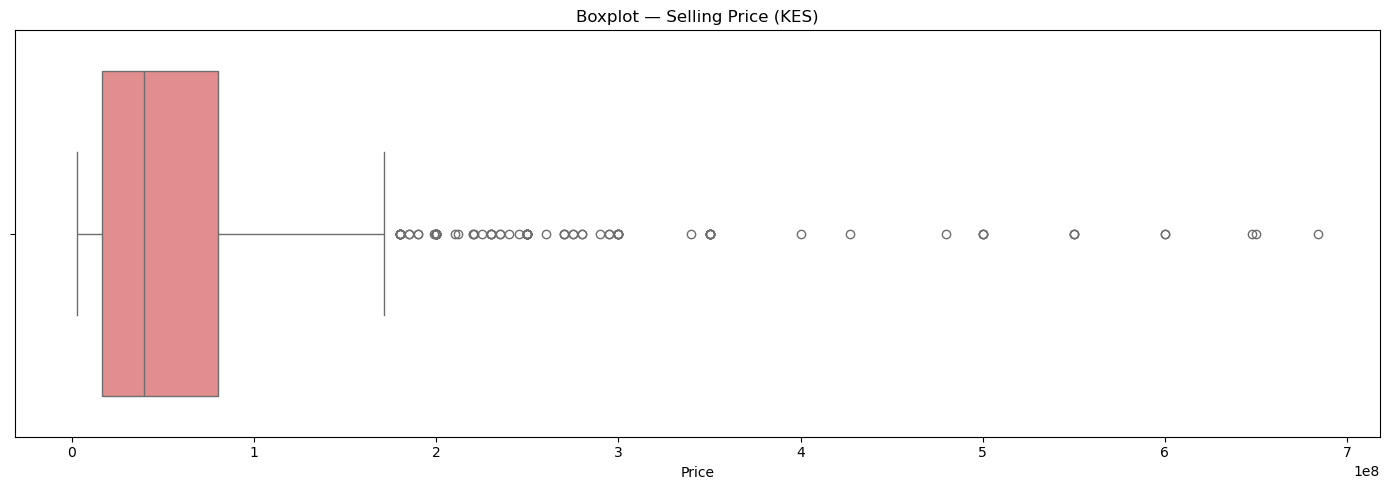

In [31]:
# Boxplot — SELLING PRICE 
plt.figure(figsize=(14, 5))
sns.boxplot(x=df1['SELLING PRICE'], color='lightcoral')
plt.title('Boxplot — Selling Price (KES)')
plt.xlabel('Price')
plt.tight_layout()
plt.show()

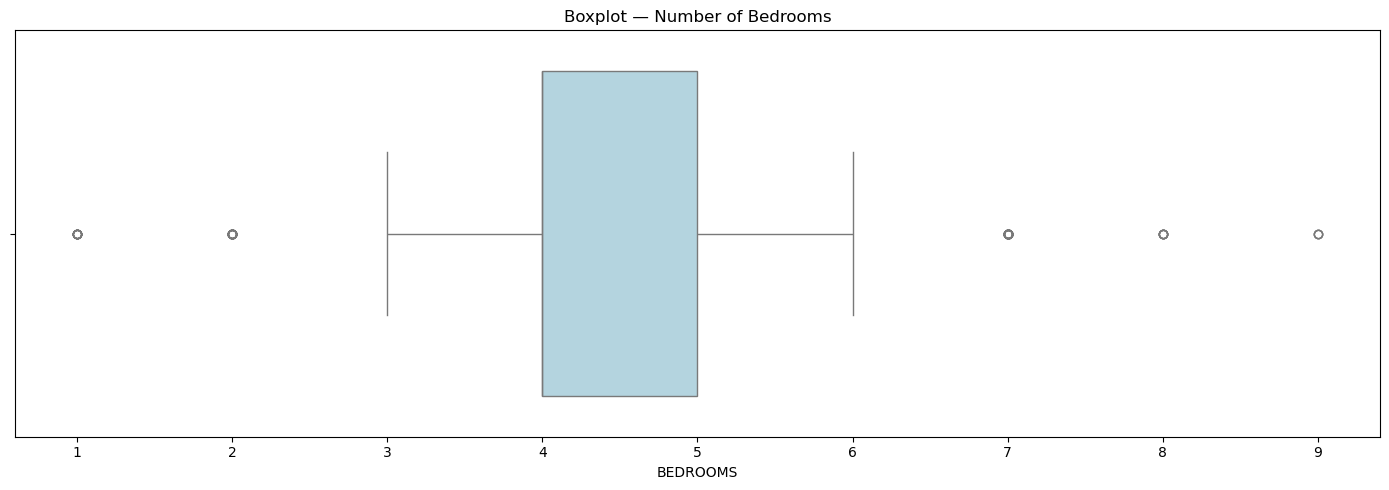

In [32]:
# Boxplot — BEDROOMS 
plt.figure(figsize=(14, 5))
sns.boxplot(x=df1['BEDROOMS'], color='lightblue')
plt.title('Boxplot — Number of Bedrooms')
plt.tight_layout()
plt.show()

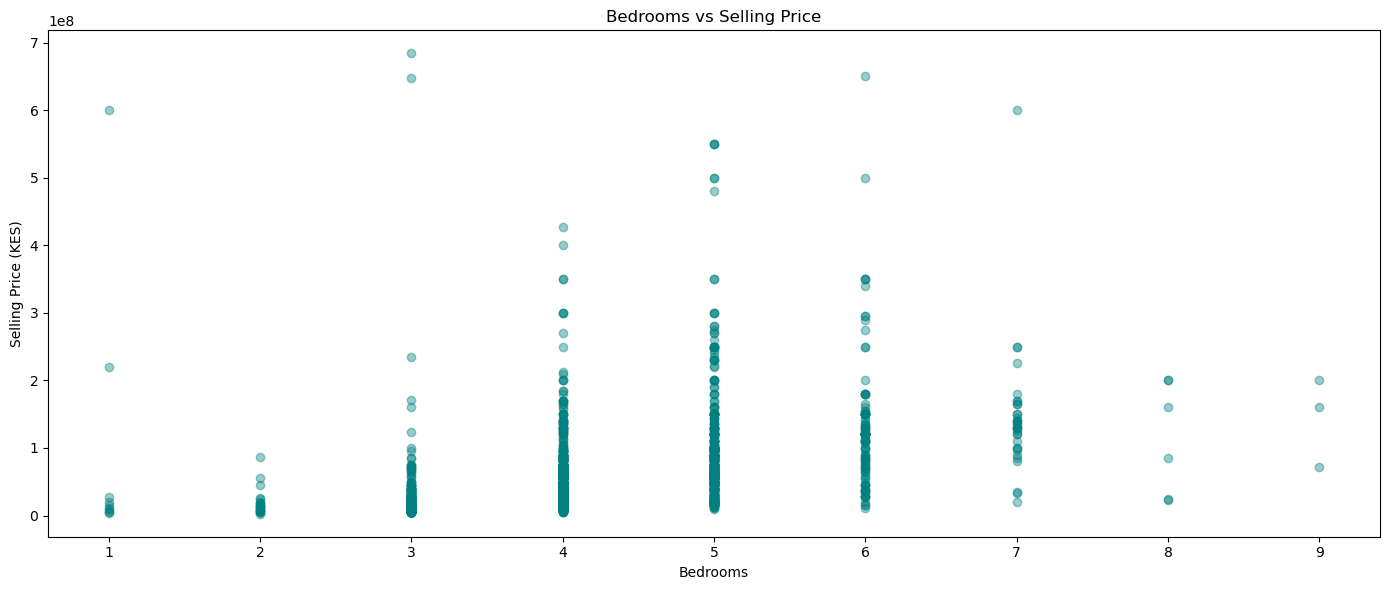

In [33]:
# Scatterplot — Bedrooms vs Price 
plt.figure(figsize=(14, 6))
plt.scatter(df1['BEDROOMS'], df1['SELLING PRICE'], alpha=0.4, color='teal')
plt.title('Bedrooms vs Selling Price')
plt.xlabel('Bedrooms')
plt.ylabel('Selling Price (KES)')
plt.tight_layout()
plt.show()

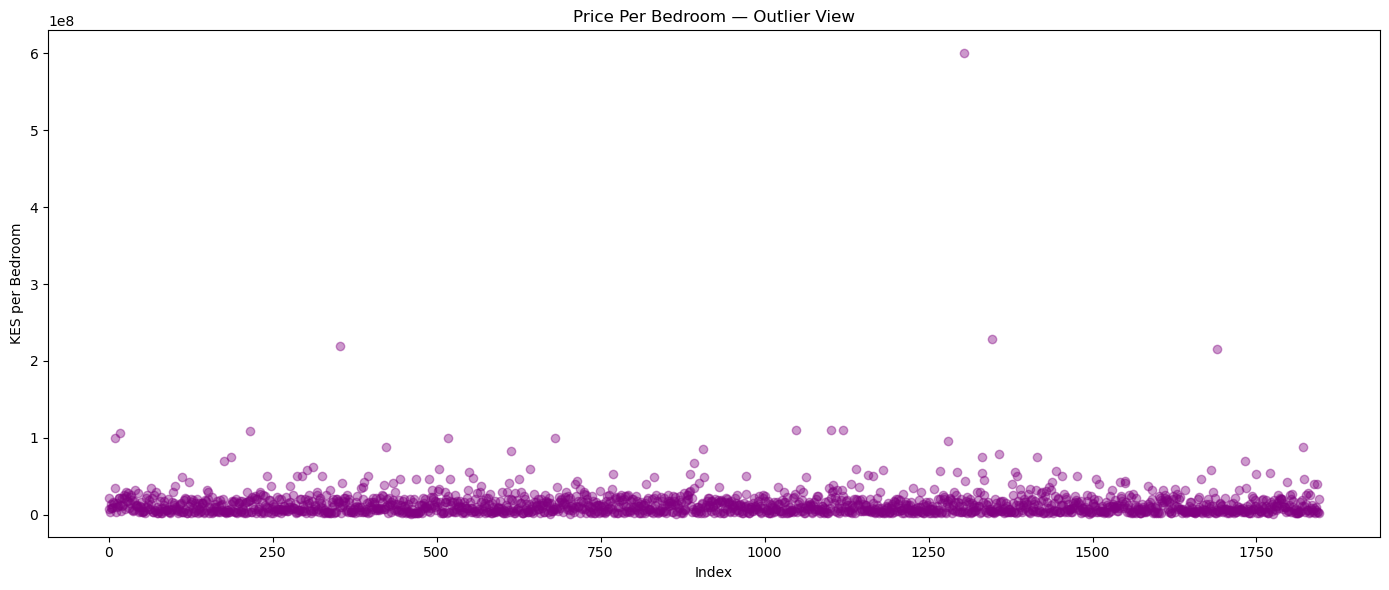

In [34]:
# Scatterplot — Price per Bedroom (outlier view) 
plt.figure(figsize=(14, 6))
plt.scatter(df1.index, df1['PRICE_PER_BEDROOM'], alpha=0.4, color='purple')
plt.title('Price Per Bedroom — Outlier View')
plt.xlabel('Index')
plt.ylabel('KES per Bedroom')
plt.tight_layout()
plt.show()

In [35]:
# IQR Method on SELLING PRICE 
# WHY: IQR is robust to extreme values and is the industry standard for price outlier detection in real estate datasets.

Q1 = df1['SELLING PRICE'].quantile(0.25)
Q3 = df1['SELLING PRICE'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1:,.0f} | Q3: {Q3:,.0f} | IQR: {IQR:,.0f}")
print(f"Lower Bound: {lower_bound:,.0f}")
print(f"Upper Bound: {upper_bound:,.0f}")

outliers_price = df1[(df1['SELLING PRICE'] < lower_bound) | (df1['SELLING PRICE'] > upper_bound)]
print(f"\nOutliers detected by IQR: {len(outliers_price)}")

Q1: 16,499,500 | Q3: 80,000,000 | IQR: 63,500,500
Lower Bound: -78,751,250
Upper Bound: 175,250,750

Outliers detected by IQR: 91


### Domain-Based Filtering 
##### WHY: In Kenyan real estate, properties below KES 2M are almost certainly data errors or plots (not houses). Properties above KES 500M are ultra-luxury outliers that distort model learning for the majority of properties. We use percentile capping as a secondary filter.

In [36]:
price_min = df1['SELLING PRICE'].quantile(0.01)   # 1st percentile
price_max = df1['SELLING PRICE'].quantile(0.99)   # 99th percentile

print(f"1st percentile price:  KES {price_min:,.0f}")
print(f"99th percentile price: KES {price_max:,.0f}")

# Apply combined domain + percentile filter
df2 = df1[
    (df1['SELLING PRICE'] >= price_min) &
    (df1['SELLING PRICE'] <= price_max) &
    (df1['BEDROOMS'] >= 1) &
    (df1['BEDROOMS'] <= 9)
].copy()

print(f"\nShape before outlier removal: {df1.shape}")
print(f"Shape after outlier removal:  {df2.shape}")
print(f"Rows removed: {df1.shape[0] - df2.shape[0]}")

1st percentile price:  KES 5,500,000
99th percentile price: KES 350,000,000

Shape before outlier removal: (1847, 13)
Shape after outlier removal:  (1818, 13)
Rows removed: 29


In [37]:
# Re-apply encoding on cleaned df2 
# WHY: We must re-encode on the cleaned dataset to ensure no ghost categories from removed rows persist.

df2_encoded = pd.get_dummies(
    df2,
    columns=['PROPERTY TYPE', 'LOCATION', 'BEDROOM_TIER', 'LOCATION_TIER'],
    drop_first=False
)

# Drop helper columns not used in modeling
df2_encoded.drop(columns=['PRICE_PER_BEDROOM'], inplace=True)

print("Final encoded shape:", df2_encoded.shape)
df2_encoded.head(3)

Final encoded shape: (1818, 52)


,BEDROOMS,HAS GYM,EN SUITE,SWIMMING POOL,Has DSQ,Has GARDEN,SELLING PRICE,AMENITY_SCORE,PROPERTY TYPE_House,PROPERTY TYPE_NOT PROVIDED,...,LOCATION_Vipingo,LOCATION_Westlands,LOCATION_other,BEDROOM_TIER_Large,BEDROOM_TIER_Luxury,BEDROOM_TIER_Medium,BEDROOM_TIER_Small,LOCATION_TIER_Affordable,LOCATION_TIER_Mid,LOCATION_TIER_Premium
0,6,0,1,0,0,0,130000000,1,False,False,...,False,False,False,True,False,False,False,False,True,False
1,4,0,1,0,1,0,26950000,2,False,False,...,False,False,False,False,False,True,False,False,True,False
2,4,0,1,0,0,0,16000000,1,False,False,...,False,False,False,False,False,True,False,True,False,False


## MODEL BUILDING & EVALUATION

In [38]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ── 3.1  Define Features and Target ──────────────────────────
X = df2_encoded.drop(columns=['SELLING PRICE'])
y = df2_encoded['SELLING PRICE']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (1818, 51)
Target shape: (1818,)


In [39]:
# Train / Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 1454 | Test size: 364


In [41]:
# Model Evaluation Helper Function 
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2   = r2_score(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Cross-validation R² (5-fold)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    cv_mean   = cv_scores.mean()

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  R²       : {r2:.4f}")
    print(f"  MAE      : KES {mae:,.0f}")
    print(f"  RMSE     : KES {rmse:,.0f}")
    print(f"  CV R²    : {cv_mean:.4f} (+/- {cv_scores.std():.4f})")

    return {
        'Model'  : name,
        'R²'     : round(r2, 4),
        'MAE'    : round(mae, 0),
        'RMSE'   : round(rmse, 0),
        'CV R²'  : round(cv_mean, 4)
    }

In [42]:
#Train All Models 
results = []

# Linear Regression
results.append(evaluate_model(
    'Linear Regression',
    LinearRegression(),
    X_train, X_test, y_train, y_test
))

# Ridge Regression
results.append(evaluate_model(
    'Ridge Regression',
    Ridge(alpha=10),
    X_train, X_test, y_train, y_test
))

# Lasso Regression
results.append(evaluate_model(
    'Lasso Regression',
    Lasso(alpha=1000),
    X_train, X_test, y_train, y_test
))

# Decision Tree
results.append(evaluate_model(
    'Decision Tree',
    DecisionTreeRegressor(random_state=42),
    X_train, X_test, y_train, y_test
))

# Random Forest
results.append(evaluate_model(
    'Random Forest',
    RandomForestRegressor(n_estimators=100, random_state=42),
    X_train, X_test, y_train, y_test
))

# Gradient Boosting
results.append(evaluate_model(
    'Gradient Boosting',
    GradientBoostingRegressor(n_estimators=200, random_state=42),
    X_train, X_test, y_train, y_test
))


  Linear Regression
  R²       : 0.5371
  MAE      : KES 26,044,168
  RMSE     : KES 40,837,479
  CV R²    : 0.4634 (+/- 0.0450)

  Ridge Regression
  R²       : 0.5207
  MAE      : KES 26,050,495
  RMSE     : KES 41,554,279
  CV R²    : 0.4683 (+/- 0.0295)

  Lasso Regression
  R²       : 0.5371
  MAE      : KES 26,037,600
  RMSE     : KES 40,838,700
  CV R²    : 0.4636 (+/- 0.0449)

  Decision Tree
  R²       : 0.2913
  MAE      : KES 27,552,730
  RMSE     : KES 50,529,435
  CV R²    : 0.3429 (+/- 0.0768)

  Random Forest
  R²       : 0.4873
  MAE      : KES 25,310,570
  RMSE     : KES 42,976,520
  CV R²    : 0.4493 (+/- 0.0509)

  Gradient Boosting
  R²       : 0.5608
  MAE      : KES 23,980,332
  RMSE     : KES 39,779,841
  CV R²    : 0.4526 (+/- 0.0348)


In [43]:
# Performance Comparison Table 
results_df = pd.DataFrame(results).sort_values('R²', ascending=False)
print("\n📊 MODEL PERFORMANCE COMPARISON")
print(results_df.to_string(index=False))


📊 MODEL PERFORMANCE COMPARISON
            Model     R²        MAE       RMSE  CV R²
Gradient Boosting 0.5608 23980332.0 39779841.0 0.4526
Linear Regression 0.5371 26044168.0 40837479.0 0.4634
 Lasso Regression 0.5371 26037600.0 40838700.0 0.4636
 Ridge Regression 0.5207 26050495.0 41554279.0 0.4683
    Random Forest 0.4873 25310570.0 42976520.0 0.4493
    Decision Tree 0.2913 27552730.0 50529435.0 0.3429


In [44]:
# Hyperparameter Tuning — Random Forest 
# WHY: Random Forest typically wins on tabular datasets with mixed feature types. We tune it to squeeze out best performance.

param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4]
}

rf_tuned = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

rf_tuned.fit(X_train, y_train)

print("Best Parameters:", rf_tuned.best_params_)
print("Best CV R²:", round(rf_tuned.best_score_, 4))

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}
Best CV R²: 0.477


In [45]:
# Evaluate Tuned Random Forest 
best_rf = rf_tuned.best_estimator_

results.append(evaluate_model(
    'Random Forest (Tuned)',
    best_rf,
    X_train, X_test, y_train, y_test
))

results_df = pd.DataFrame(results).sort_values('R²', ascending=False)
print("\n📊 FINAL MODEL COMPARISON (with Tuned RF)")
print(results_df.to_string(index=False))


  Random Forest (Tuned)
  R²       : 0.5323
  MAE      : KES 24,628,045
  RMSE     : KES 41,049,534
  CV R²    : 0.4770 (+/- 0.0281)

📊 FINAL MODEL COMPARISON (with Tuned RF)
                Model     R²        MAE       RMSE  CV R²
    Gradient Boosting 0.5608 23980332.0 39779841.0 0.4526
    Linear Regression 0.5371 26044168.0 40837479.0 0.4634
     Lasso Regression 0.5371 26037600.0 40838700.0 0.4636
Random Forest (Tuned) 0.5323 24628045.0 41049534.0 0.4770
     Ridge Regression 0.5207 26050495.0 41554279.0 0.4683
        Random Forest 0.4873 25310570.0 42976520.0 0.4493
        Decision Tree 0.2913 27552730.0 50529435.0 0.3429


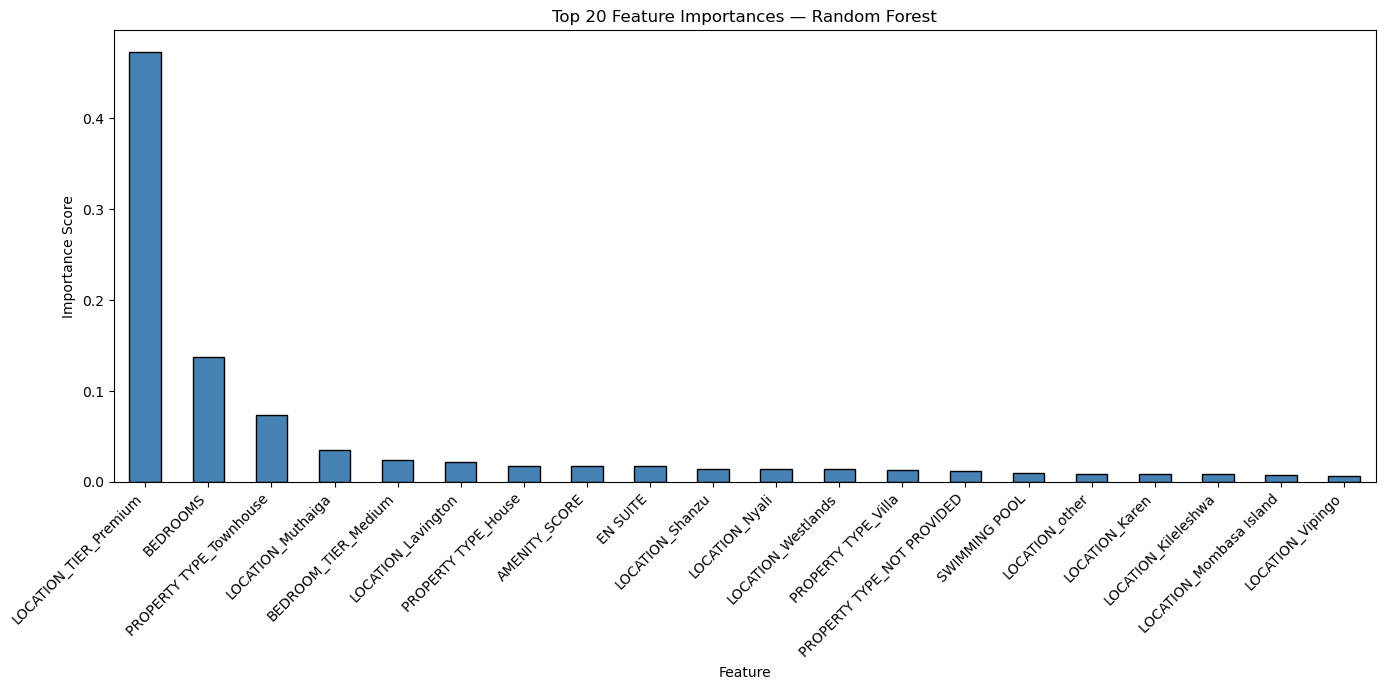

In [47]:
# Feature Importance Plot 
feat_importances = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(20)

plt.figure(figsize=(14, 7))
feat_importances.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 20 Feature Importances — Random Forest')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [67]:
# ── 3.9 Save the Final Model ─────────────────────────────────

import joblib
import pickle
import json
import os

# Ensure model directory exists
MODEL_DIR = "model"
os.makedirs(MODEL_DIR, exist_ok=True)

# File paths
joblib_path = os.path.join(MODEL_DIR, "real_estate_model.joblib")
pkl_path = os.path.join(MODEL_DIR, "real_estate_model.pkl")
json_path = os.path.join(MODEL_DIR, "columns.json")

# ── Save model using joblib (best for sklearn)
joblib.dump(best_rf, joblib_path)

# ── Save backup using pickle
with open(pkl_path, "wb") as f:
    pickle.dump(best_rf, f)

# ── Save feature columns (EXCLUDING target column)
columns = {
    "data_columns": X.columns.tolist()
}

with open(json_path, "w") as f:
    json.dump(columns, f, indent=2)

# ── Confirmation logs
print("✅ Model saved to:", joblib_path)
print("✅ Backup saved to:", pkl_path)
print("✅ Columns saved to:", json_path)
print(f"✅ Total features: {len(X.columns)}")

✅ Model saved to: model\real_estate_model.joblib
✅ Backup saved to: model\real_estate_model.pkl
✅ Columns saved to: model\columns.json
✅ Total features: 51


In [66]:
import json

columns = {
    "columns": [
        "BEDROOMS",
        "PROPERTY TYPE",
        "HAS GYM",
        "EN SUITE",
        "SWIMMING POOL",
        "Has DSQ",
        "Has GARDEN",
        "LOCATION"
    ]
}

with open("columns.json", "w") as f:
    json.dump(columns, f)

In [58]:
!pip install flask-cors